# Train Sentiment Models

This notebook follows your provided code structure with fixes applied:
- Normalize smart quotes
- Split **before** upsampling (prevent leakage)
- TF-IDF with `stop_words='english'` and `min_df=2`
- Safe `custom_predict` using `model.classes_`

Dataset path used:
```
/mnt/data/synthetic_3000_unique_rows.csv
```

In [11]:
# Step 1: Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
import nltk
import re
import string
from wordcloud import WordCloud
import pickle
from sklearn.utils import resample

nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\shikh\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [12]:
# Step 2: Load Dataset
data_path = r"reviews.csv"
data = pd.read_csv(data_path)
print("Loaded dataset shape:", data.shape)
data.head()

Loaded dataset shape: (50000, 4)


,Score,Text,clean_text,sentiment
0,4,Perfect! Works as expected.,perfect works as expected,positive
1,2,"ABSOLUTE TRASH, AVOID AT ALL COSTS.",absolute trash avoid at all costs,negative
2,3,"firm speaker Not bad, could be better. so-so",firm speaker not bad could be better so so,neutral
3,1,"TERRIBLE QUALITY, NOT RECOMMENDED. SAHI HAI",terrible quality not recommended sahi hai,negative
4,2,"DURABLE MUG BROKE WITHIN A DAY, AWFUL. RIPOFF ...",durable mug broke within a day awful ripoff kh...,negative


In [13]:
# Step 3: Text Cleaning (preserve negations) and normalize smart quotes
def clean_text(text):
    text = str(text)
    # normalize smart quotes
    text = text.replace("’", "'").replace("‘", "'").replace("“", '"').replace("”", '"')
    text = text.lower()
    # preserve n't as " not"
    text = re.sub(r"n\'t", " not", text)
    # remove straight apostrophes
    text = re.sub(r"'", "", text)
    # remove digits
    text = re.sub(r"\d+", "", text)
    # remove punctuation
    text = text.translate(str.maketrans("", "", string.punctuation))
    text = " ".join(text.split())
    return text

# Apply cleaning and create sentiment label (positive if Score >=4)
data['clean_text'] = data['Text'].apply(clean_text)
data['sentiment'] = data['Score'].apply(lambda x: 'positive' if x >= 4 else 'negative')
data[['Text','clean_text','Score','sentiment']].head()

,Text,clean_text,Score,sentiment
0,Perfect! Works as expected.,perfect works as expected,4,positive
1,"ABSOLUTE TRASH, AVOID AT ALL COSTS.",absolute trash avoid at all costs,2,negative
2,"firm speaker Not bad, could be better. so-so",firm speaker not bad could be better soso,3,negative
3,"TERRIBLE QUALITY, NOT RECOMMENDED. SAHI HAI",terrible quality not recommended sahi hai,1,negative
4,"DURABLE MUG BROKE WITHIN A DAY, AWFUL. RIPOFF ...",durable mug broke within a day awful ripoff kh...,2,negative


In [14]:
# Step 4: Train-Test Split (split BEFORE upsampling to prevent leakage)
X = data['clean_text']
y = data['sentiment']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print("Train size:", len(X_train), "Test size:", len(X_test))

# Now upsample minority class only in the training set
train_df = pd.DataFrame({'clean_text': X_train, 'sentiment': y_train})
pos = train_df[train_df.sentiment == 'positive']
neg = train_df[train_df.sentiment == 'negative']

if len(pos) > len(neg):
    neg_up = resample(neg, replace=True, n_samples=len(pos), random_state=42)
    train_bal = pd.concat([pos, neg_up]).sample(frac=1, random_state=42)
else:
    pos_up = resample(pos, replace=True, n_samples=len(neg), random_state=42)
    train_bal = pd.concat([neg, pos_up]).sample(frac=1, random_state=42)

X_train = train_bal['clean_text']
y_train = train_bal['sentiment']

print("After balancing (train only) class counts:\n", y_train.value_counts())

Train size: 35000 Test size: 15000
After balancing (train only) class counts:
 sentiment
negative    19250
positive    19250
Name: count, dtype: int64


In [15]:
# Step 6: TF-IDF (with stop words removal and min_df)
tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1,2), stop_words='english', min_df=2)
X_train_vec = tfidf.fit_transform(X_train)
X_test_vec = tfidf.transform(X_test)

print("TF-IDF shape (train):", X_train_vec.shape)

TF-IDF shape (train): (38500, 5000)



Logistic Regression Classification Report:

              precision    recall  f1-score   support

    negative       0.99      1.00      0.99      8250
    positive       0.99      0.99      0.99      6750

    accuracy                           0.99     15000
   macro avg       0.99      0.99      0.99     15000
weighted avg       0.99      0.99      0.99     15000



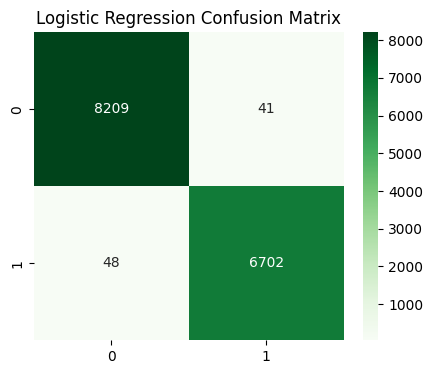

LR classes: ['negative' 'positive']


In [16]:
# Step 7: Logistic Regression with class weights
lr_model = LogisticRegression(class_weight='balanced', max_iter=300, random_state=42)
lr_model.fit(X_train_vec, y_train)
y_pred_lr = lr_model.predict(X_test_vec)

print("\nLogistic Regression Classification Report:\n")
print(classification_report(y_test, y_pred_lr))

plt.figure(figsize=(5,4))
sns.heatmap(confusion_matrix(y_test, y_pred_lr), annot=True, fmt='d', cmap="Greens")
plt.title("Logistic Regression Confusion Matrix")
plt.show()

# Print classes and a few coefficients for inspection
print("LR classes:", lr_model.classes_)


Naive Bayes Classification Report:

              precision    recall  f1-score   support

    negative       1.00      0.99      0.99      8250
    positive       0.99      1.00      0.99      6750

    accuracy                           0.99     15000
   macro avg       0.99      0.99      0.99     15000
weighted avg       0.99      0.99      0.99     15000



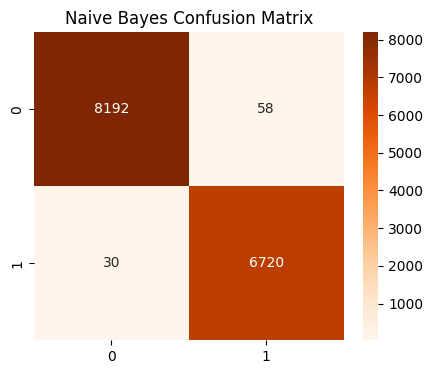

NB classes: ['negative' 'positive']


In [17]:
# Step 8: Naive Bayes Model
nb_model = MultinomialNB()
nb_model.fit(X_train_vec, y_train)
y_pred_nb = nb_model.predict(X_test_vec)

print("\nNaive Bayes Classification Report:\n")
print(classification_report(y_test, y_pred_nb))
plt.figure(figsize=(5,4))
sns.heatmap(confusion_matrix(y_test, y_pred_nb), annot=True, fmt='d', cmap="Oranges")
plt.title("Naive Bayes Confusion Matrix")
plt.show()

print("NB classes:", nb_model.classes_)

In [18]:
# Step 9: Custom prediction function with threshold (safe)
def custom_predict(model, vectorizer, texts, threshold=0.55, positive_label='positive'):
    vec = vectorizer.transform([clean_text(t) for t in texts])
    if hasattr(model, "predict_proba"):
        probs = model.predict_proba(vec)
        try:
            pos_idx = list(model.classes_).index(positive_label)
        except ValueError:
            pos_idx = 1 if probs.shape[1] > 1 else 0
        return ["positive" if p[pos_idx] >= threshold else "negative" for p in probs]
    else:
        return list(model.predict(vec))

# Quick check
sample_reviews = [
    "disappointed with the product",
    "the product is worthless",
    "the product is worth it",
    "I love this product, it's fantastic!",
    "Worst experience ever"
]

print("LR predictions:", custom_predict(lr_model, tfidf, sample_reviews, threshold=0.55))
print("NB predictions:", custom_predict(nb_model, tfidf, sample_reviews, threshold=0.55))

LR predictions: ['negative', 'negative', 'positive', 'positive', 'negative']
NB predictions: ['negative', 'negative', 'positive', 'positive', 'negative']


In [19]:
# Step 10: Save Logistic Regression + Naive Bayes models + vectorizer
import os
os.makedirs("models1", exist_ok=True)

with open("models1/sentiment_lr_model.pkl", "wb") as f:
    pickle.dump(lr_model, f)

with open("models1/sentiment_nb_model.pkl", "wb") as f:
    pickle.dump(nb_model, f)

with open("models1/tfidf_vectorizer.pkl", "wb") as f:
    pickle.dump(tfidf, f)

print("\nModels trained and saved to models1/")


Models trained and saved to models1/


In [20]:
# Step 11: Sample Predictions
sample_reviews = [
    "I love this product, it’s amazing and works great!",
    "Worst experience ever, totally waste of money.",
    "It’s decent, not too good not too bad.",
    "The product is not good at all, very disappointing.",
    "I don’t like this product, it’s awful."
]

print("\nSample Predictions (Logistic Regression, threshold=0.55):")
print(custom_predict(lr_model, tfidf, sample_reviews, threshold=0.55))

print("\nSample Predictions (Naive Bayes):")
print(custom_predict(nb_model, tfidf, sample_reviews, threshold=0.55))


Sample Predictions (Logistic Regression, threshold=0.55):
['positive', 'negative', 'negative', 'positive', 'negative']

Sample Predictions (Naive Bayes):
['positive', 'negative', 'negative', 'negative', 'negative']
